In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv.csv")

In [4]:
df.isna().sum()
df.dropna(inplace=True)

In [5]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [6]:
scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [10]:
df.describe()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,8.830000e+02,8.830000e+02,8.830000e+02,8.830000e+02,8.830000e+02,8.830000e+02,8.830000e+02,8.830000e+02,8.830000e+02
mean,6.437533e-17,-1.408210e-16,-5.029323e-17,5.230496e-17,-3.419940e-17,-7.242225e-17,1.287507e-16,2.011729e-18,-1.569149e-16
std,1.000567e+00,1.000567e+00,1.000567e+00,1.000567e+00,1.000567e+00,1.000567e+00,1.000567e+00,1.000567e+00,1.000567e+00
min,-1.762254e+00,-1.664202e+00,-8.811317e-01,-1.588061e+00,-1.254586e+00,-8.998920e-01,-1.656437e+00,-1.588713e+00,-2.246485e+00
25%,-8.500420e-01,-8.656594e-01,-8.811317e-01,-2.614216e-01,-1.254586e+00,-8.998920e-01,-8.295451e-01,-9.039030e-01,-7.156073e-01
50%,1.351862e-02,4.017591e-02,-1.580469e-01,-2.614216e-01,-2.085053e-01,-8.998920e-01,-2.653296e-03,1.233124e-01,-6.614416e-02
75%,8.701291e-01,8.747756e-01,5.650380e-01,1.065218e+00,8.375754e-01,1.396653e+00,8.242385e-01,8.081227e-01,6.760994e-01
max,1.709364e+00,1.748071e+00,2.011208e+00,1.065218e+00,1.883656e+00,1.396653e+00,1.651130e+00,1.492933e+00,3.923415e+00


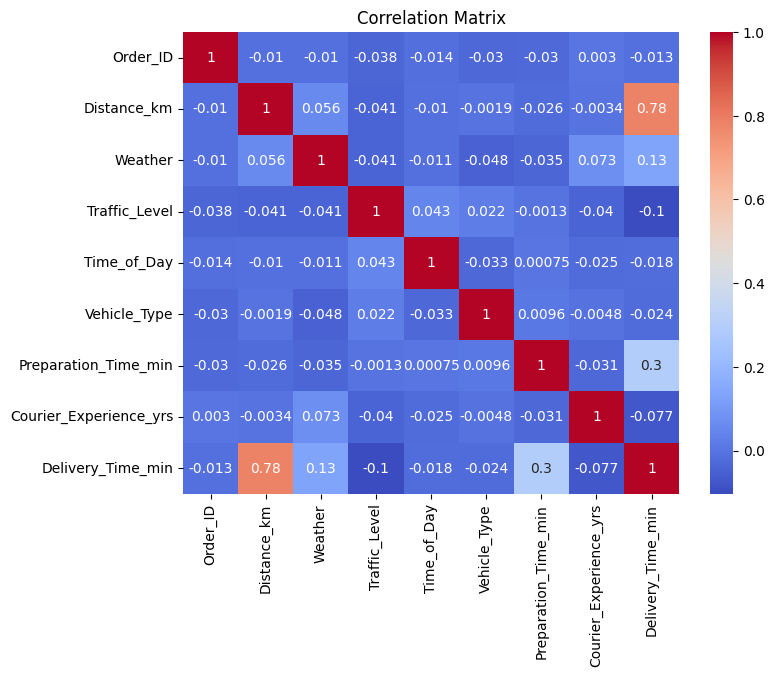

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

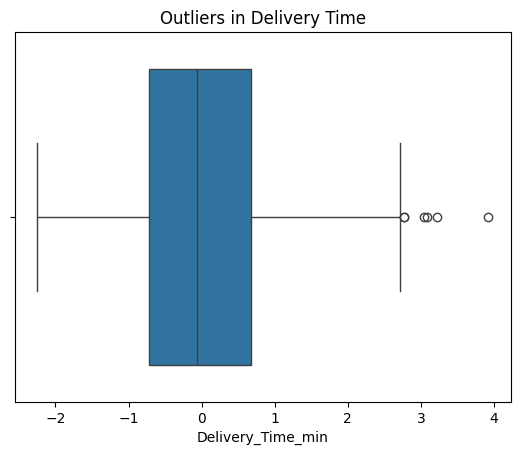

In [16]:
plt.figure()
sns.boxplot(x=df['Delivery_Time_min'])
plt.title("Outliers in Delivery Time")
plt.show()


In [17]:
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
lr=LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Linear Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Linear Regression Results:
MSE: 0.19861037591055358
MAE: 0.3225887319411217
R2 Score: 0.774200529473385


In [22]:
median_time = df["Delivery_Time_min"].median()
df["Delivery_Status"] = (df["Delivery_Time_min"] > median_time).astype(int)

X = df.drop(["Delivery_Time_min", "Delivery_Status"], axis=1)
y = df["Delivery_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))



Logistic Regression Results:
Accuracy: 0.864406779661017
Precision: 0.7721518987341772
Recall: 0.9104477611940298
F1 Score: 0.8356164383561644


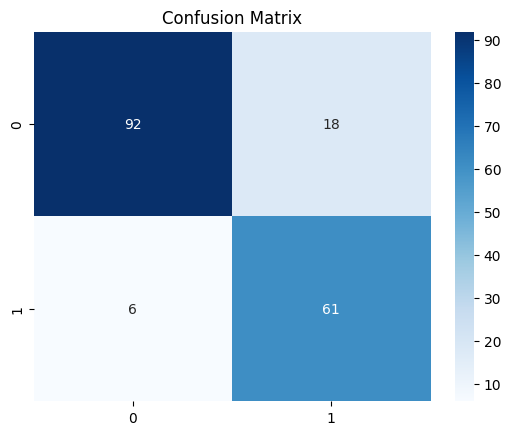

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()